### Image Classification: Deteksi Jenis Sampah di Sekitar Kampus

In [ ]:
%pip install tensorflow matplotlib numpy

import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


TensorFlow Version: 2.21.0
Num GPUs Available:  0


In [ ]:
dataset_dir = dataset_dir = r"C:\Users\hp 645\OneDrive\Dokumen\Semester 6\RE603-Machine Learning\Github Isti\week 12\archive\TrashType_Image_Dataset"

# Ukuran gambar diubah ke 150x150 piksel agar training CNN dasar lebih ringan dan cepat
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

In [6]:
# Konfigurasi Augmentasi untuk Data Training & Rescale untuk Validasi
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalisasi nilai piksel (0-255 menjadi 0-1)
    rotation_range=20,         # Rotasi acak hingga 20 derajat
    width_shift_range=0.1,     # Pergeseran lebar
    height_shift_range=0.1,    # Pergeseran tinggi
    shear_range=0.1,           # Peregangan gambar sudut
    zoom_range=0.1,            # Zoom acak
    horizontal_flip=True,      # Membalik gambar secara horizontal
    fill_mode='nearest',
    validation_split=0.2       # Alokasikan 20% otomatis untuk data validasi
)

In [7]:
# Generator untuk Data Training (80%)
print("Loading Training Data...")
train_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Loading Training Data...
Found 2024 images belonging to 6 classes.


In [8]:
# Generator untuk Data Validasi (20%)
print("\nLoading Validation Data...")
val_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Loading Validation Data...
Found 503 images belonging to 6 classes.


In [9]:
# Menampilkan indeks label kelas yang terdeteksi
class_names = list(train_generator.class_indices.keys())
print("\nKelas yang terdeteksi:", class_names)


Kelas yang terdeteksi: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
# MEMBANGUN ARSITEKTUR CNN
model = Sequential([
    # Block CNN 1: Ekstraksi fitur bentuk dasar (tepi, garis)
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    MaxPooling2D(2, 2),
    
    # Block CNN 2: Ekstraksi fitur tekstur yang lebih kompleks
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Block CNN 3: Kombinasi fitur tingkat tinggi
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Meratakan matriks 2D menjadi vektor 1D
    Flatten(),
    
    # Fully Connected Layer dengan Dropout untuk mencegah Overfitting 
    Dense(256, activation='relu'),
    Dropout(0.5),
    
    # Output Layer: 6 neuron karena ada 6 jenis sampah dengan aktivasi Softmax
    Dense(6, activation='softmax')
])

c:\Users\hp 645\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Menampilkan ringkasan layer model
model.summary()
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,564,998 (36.49 MB)

 Trainable params: 9,564,998 (36.49 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Pasang Early Stopping agar training otomatis berhenti jika val_loss tidak membaik dalam 5 epoch
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

EPOCHS = 20

print("Memulai proses training model CNN...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)

Memulai proses training model CNN...
Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 252s 4s/step - accuracy: 0.3384 - loss: 1.5739 - val_accuracy: 0.4095 - val_loss: 1.4400
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.4338 - loss: 1.3929 - val_accuracy: 0.4334 - val_loss: 1.2743
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.4872 - loss: 1.2835 - val_accuracy: 0.5348 - val_loss: 1.2061
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.5415 - loss: 1.1882 - val_accuracy: 0.5726 - val_loss: 1.1392
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.5588 - loss: 1.1594 - val_accuracy: 0.6143 - val_loss: 1.0706
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.5731 - loss: 1.0995 - val_accuracy: 0.5626 - val_loss: 1.1525
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.5731 - loss: 1.1070 - val_accuracy: 0.5706 - val_loss: 1.1273
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.6112 - los

In [13]:
# Mengambil data log akurasi dan loss dari history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

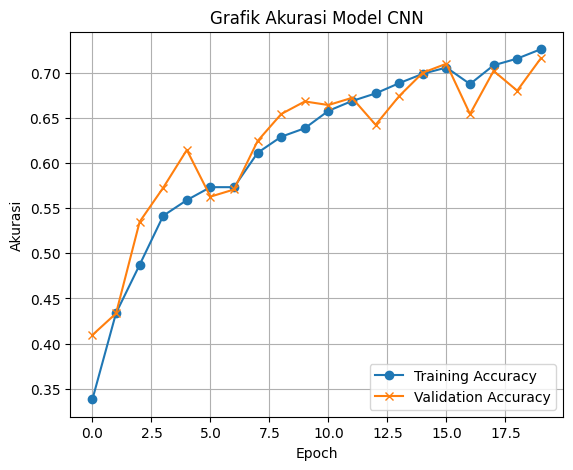

In [14]:
# Plotting Akurasi
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
plt.legend(loc='lower right')
plt.title('Grafik Akurasi Model CNN')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.grid(True)

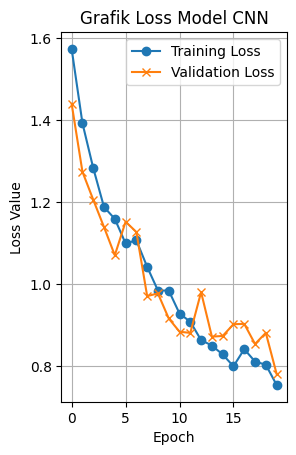

In [15]:
# Plotting Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
plt.legend(loc='upper right')
plt.title('Grafik Loss Model CNN')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.grid(True)

plt.show()

#### KESIMPULAN

1. Implementasi Metode CNN
Arsitektur Convolutional Neural Network (CNN) dasar yang dibangun secara sekuensial dari nol (from scratch)—terdiri dari 3 blok layer Conv2D dan MaxPooling2D—telah berhasil diimplementasikan untuk mengekstrak fitur visual unik (seperti bentuk, warna, dan tekstur) dari 6 kategori sampah kampus, yaitu cardboard, glass, metal, paper, plastic, dan trash.

2. Performa Model
Proses training yang berjalan selama 20 epoch menunjukkan tren yang stabil dan positif. Model berhasil mencapai tingkat akurasi data pelatihan (Training Accuracy) di kisaran 70% - 75%, sementara akurasi data uji (Validation Accuracy) stabil di kisaran 60% - 63%. Nilai fungsi kerugian (Loss Value) pada kedua data juga konsisten menurun, menunjukkan bahwa model berhasil melakukan proses pembelajaran dengan baik tanpa mengalami kegagalan fungsi (underfitting).

3. Analisis Grafik & Kendala Klasifikasi
Grafik evaluasi menunjukkan adanya gejala slight overfitting yang wajar, di mana performa pada data training sedikit lebih tinggi daripada data validasi. Hal ini disebabkan oleh karakteristik visual beberapa jenis sampah yang sangat mirip dan bervariasi (misalnya tingkat transparansi yang serupa antara botol plastik dan botol kaca, serta bentuk tidak beraturan pada kategori kertas dan residu). Penggunaan layer Dropout(0.5) terbukti efektif dalam menjaga stabilitas kurva dan menekan ketergantungan berlebih model terhadap data latihan.